In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("data/transactions.csv")

df.head()

,transaction_id,kunden_id,datum,typetransaktion,betrag
0,T001,K001,2026-01-03,Überweisung,450
1,T002,K002,2026-01-04,Abhebung,120
2,T003,K001,2026-01-05,Zahlung,75
3,T004,K003,2026-01-05,Überweisung,1200
4,T005,K004,2026-01-06,Zahlung,45


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   transaction_id   25 non-null     str  
 1   kunden_id        25 non-null     str  
 2   datum            25 non-null     str  
 3   typetransaktion  25 non-null     str  
 4   betrag           25 non-null     str  
dtypes: str(5)
memory usage: 1.1 KB


In [4]:
df.shape

(25, 5)

In [6]:
df.isnull().sum()

transaction_id     0
kunden_id          0
datum              0
typetransaktion    0
betrag             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["datum"] = pd.to_datetime(df["datum"])

In [9]:
df.dtypes

transaction_id                str
kunden_id                     str
datum              datetime64[us]
typetransaktion               str
betrag                        str
dtype: object

In [18]:
df["betrag"].dtype

dtype('float64')

In [17]:
df["betrag"] = pd.to_numeric(df["betrag"], errors="coerce")

In [19]:
df[df["betrag"] <= 0].head()

,transaction_id,kunden_id,datum,typetransaktion,betrag


In [20]:
df["betrag"].sum()

np.float64(20615.0)

In [21]:
df["betrag"].mean()

np.float64(858.9583333333334)

In [22]:
df["betrag"].max()

np.float64(5000.0)

In [23]:
df["betrag"].min()

np.float64(45.0)

In [24]:
df.loc[df["betrag"].idxmax()]

transaction_id                    T013
kunden_id                         K003
datum              2026-01-14 00:00:00
typetransaktion            Überweisung
betrag                          5000.0
Name: 12, dtype: object

In [25]:
connection = sqlite3.connect("banking_data.db")

In [26]:
df.to_sql("transactions", connection, if_exists="replace", index=False)

25

In [27]:
pd.read_sql_query("SELECT * FROM transactions LIMIT 5", connection)

,transaction_id,kunden_id,datum,typetransaktion,betrag
0,T001,K001,2026-01-03 00:00:00,Überweisung,450.0
1,T002,K002,2026-01-04 00:00:00,Abhebung,120.0
2,T003,K001,2026-01-05 00:00:00,Zahlung,75.0
3,T004,K003,2026-01-05 00:00:00,Überweisung,1200.0
4,T005,K004,2026-01-06 00:00:00,Zahlung,45.0


In [30]:
query = """
SELECT COUNT(*) AS anzahl_transaktionen
FROM transactions;
"""

pd.read_sql_query(query, connection)

,anzahl_transaktionen
0,25


In [31]:
query = """
SELECT SUM(betrag) AS gesamtbetrag
FROM transactions;
"""

pd.read_sql_query(query, connection)

,gesamtbetrag
0,20615.0


In [32]:
query = """
SELECT typetransaktion,
       COUNT(*) AS anzahl,
       SUM(betrag) AS gesamtbetrag
FROM transactions
GROUP BY typetransaktion
ORDER BY gesamtbetrag DESC;
"""

pd.read_sql_query(query, connection)

,typetransaktion,anzahl,gesamtbetrag
0,Überweisung,11,18900.0
1,Abhebung,6,1150.0
2,Zahlung,8,565.0


In [33]:
query = """
SELECT kunden_id,
       COUNT(*) AS anzahl_transaktionen,
       SUM(betrag) AS gesamtbetrag,
       AVG(betrag) AS durchschnittlicher_betrag
FROM transactions
GROUP BY kunden_id
ORDER BY gesamtbetrag DESC;
"""

kundenanalyse = pd.read_sql_query(query, connection)

kundenanalyse

,kunden_id,anzahl_transaktionen,gesamtbetrag,durchschnittlicher_betrag
0,K003,5,10495.0,2099.00
1,K001,6,6405.0,1067.50
2,K004,4,1755.0,438.75
3,K002,5,1270.0,254.00
4,K005,5,690.0,172.50


In [34]:
query = """
SELECT transaction_id,
       kunden_id,
       datum,
       typetransaktion,
       betrag
FROM transactions
WHERE betrag > 3000
ORDER BY betrag DESC;
"""

auffaellige_transaktionen = pd.read_sql_query(query, connection)

auffaellige_transaktionen

,transaction_id,kunden_id,datum,typetransaktion,betrag
0,T013,K003,2026-01-14 00:00:00,Überweisung,5000.0
1,T023,K003,2026-01-24 00:00:00,Überweisung,4100.0
2,T019,K001,2026-01-20 00:00:00,Überweisung,3200.0


In [35]:
query = """
SELECT kunden_id,
       COUNT(*) AS anzahl_auffaelliger_transaktionen,
       SUM(betrag) AS summe_auffaelliger_transaktionen
FROM transactions
WHERE betrag > 3000
GROUP BY kunden_id
ORDER BY summe_auffaelliger_transaktionen DESC;
"""

pd.read_sql_query(query, connection)

,kunden_id,anzahl_auffaelliger_transaktionen,summe_auffaelliger_transaktionen
0,K003,2,9100.0
1,K001,1,3200.0


In [36]:
typanalyse = pd.read_sql_query("""
SELECT typetransaktion,
       SUM(betrag) AS gesamtbetrag
FROM transactions
GROUP BY typetransaktion
ORDER BY gesamtbetrag DESC;
""", connection)

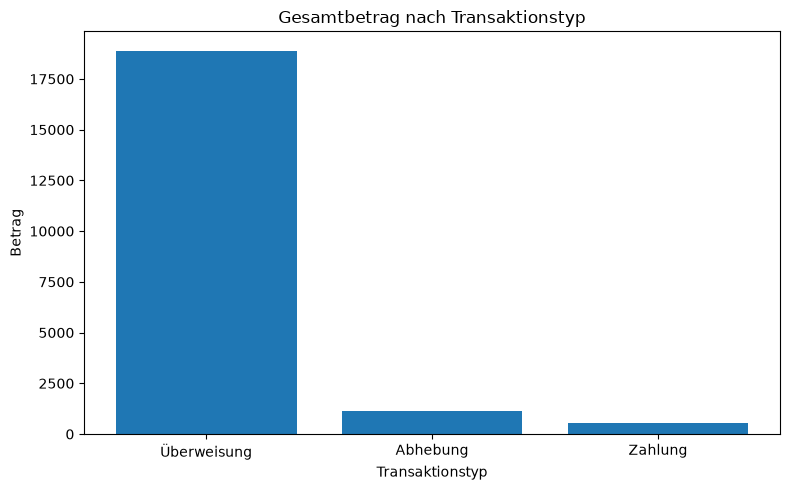

In [37]:
plt.figure(figsize=(8, 5))

plt.bar(
    typanalyse["typetransaktion"],
    typanalyse["gesamtbetrag"]
)

plt.title("Gesamtbetrag nach Transaktionstyp")
plt.xlabel("Transaktionstyp")
plt.ylabel("Betrag")

plt.tight_layout()
plt.show()

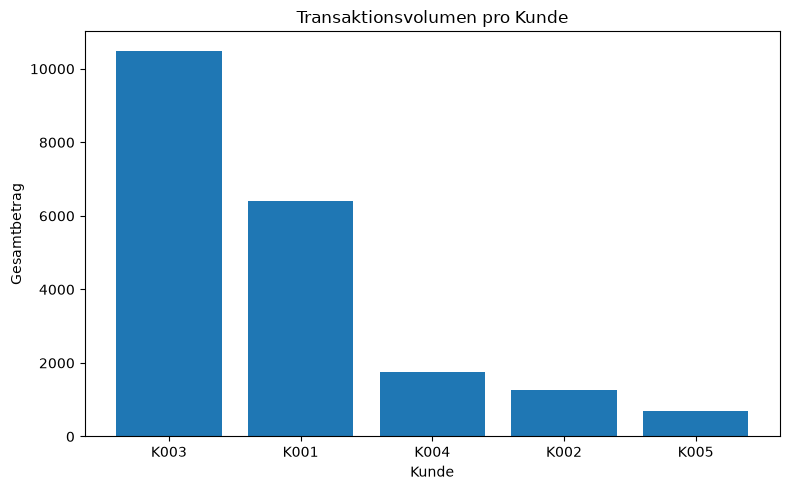

In [38]:
plt.figure(figsize=(8, 5))

plt.bar(
    kundenanalyse["kunden_id"],
    kundenanalyse["gesamtbetrag"]
)

plt.title("Transaktionsvolumen pro Kunde")
plt.xlabel("Kunde")
plt.ylabel("Gesamtbetrag")

plt.tight_layout()
plt.show()

## Ergebnisse

Die Analyse zeigt Unterschiede zwischen den Kunden und Transaktionstypen.

Einige Transaktionen weisen deutlich höhere Beträge als der Durchschnitt auf.
Besonders auffällige Transaktionen wurden mit einem Schwellenwert von 3.000 Euro identifiziert.

Kunde K003 weist mehrere hohe Transaktionsbeträge auf. 
Diese Transaktionen sind deshalb für eine weitere Prüfung interessant.

Die Analyse beweist jedoch keinen Betrug. 
Sie dient lediglich dazu, auffällige Muster in den Transaktionsdaten zu erkennen.

Durch die Kombination von Pandas, SQL und SQLite konnten die Daten
bereinigt, gespeichert, abgefragt und anschließend visualisiert werden.

In [39]:
connection.close()